In [21]:
from DeepTemporalClustering import DTC
from sklearn.preprocessing import StandardScaler
from tslearn.datasets import UCR_UEA_datasets
from matplotlib import pyplot as plt
import numpy as np
import tensorflow as tf

In [22]:
from sklearn.model_selection import train_test_split

X_test, y_test,X_train_full, y_train_full,  = UCR_UEA_datasets().load_dataset('CBF')


In [23]:
train_size = int(len(X_train_full) * 0.8)

In [24]:
X_train = X_train_full[:train_size]
y_train = y_train_full[:train_size]

X_val = X_train_full[train_size:]
y_val = y_train_full[train_size:]

In [25]:
print(f"X_train shape: {X_train.shape}\ny_train shape: {y_train.shape}\nX_val shape: {X_val.shape}\ny_val shape: {y_val.shape}")

X_train shape: (720, 128, 1)
y_train shape: (720,)
X_val shape: (180, 128, 1)
y_val shape: (180,)


In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train.reshape(-1, 2)
).reshape(X_train.shape)

X_val_scaled = scaler.transform(
    X_val.reshape(-1, 2)
).reshape(X_val.shape)

In [52]:
modelo = DTC(n_clusters = 3, timesteps = X_train.shape[1],pool_size = 8,input_dim = X_train.shape[2],n_filters = 50,kernel_size = 10,n_units = [128,64,1])
modelo.initialize()
modelo.pretrain(X_train,epochs = 25, batch_size = 32)
modelo.fit(X_train_scaled,y_train,X_val_scaled,y_val,n_clusters = 3)

Pretraining...
Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.4915
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.3132
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.2493
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2237
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2091
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1997
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1952
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1913
Epoch 9/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1888
Epoch 10/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1886
Epoch 11/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1849
Epoch 12/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1827
Epoch 13/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1819
Epoch 14/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1799
Epoch 15/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - lo

array([2, 1, 0, 1, 1, 2, 0, 2, 0, 2, 1, 2, 2, 0, 1, 2, 2, 0, 1, 1, 0, 1,
       0, 2, 1, 2, 2, 2, 2, 0, 1, 0, 0, 0, 1, 2, 1, 2, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 2, 0, 2, 2, 2, 1, 0, 1, 2, 2, 2, 2, 1, 1, 2, 1, 2, 1,
       0, 0, 1, 2, 1, 2, 0, 0, 0, 1, 1, 0, 2, 0, 0, 0, 1, 1, 0, 0, 2, 0,
       2, 0, 2, 2, 1, 0, 1, 0, 2, 0, 1, 2, 0, 0, 2, 2, 1, 2, 2, 2, 2, 1,
       2, 0, 1, 2, 2, 2, 0, 0, 0, 2, 2, 2, 1, 2, 1, 2, 1, 0, 0, 2, 2, 1,
       1, 2, 2, 1, 1, 2, 2, 0, 0, 1, 1, 0, 2, 1, 2, 0, 0, 0, 0, 2, 0, 1,
       2, 0, 1, 0, 2, 1, 1, 2, 1, 1, 2, 0, 2, 2, 2, 1, 0, 2, 1, 1, 2, 2,
       0, 1, 2, 1, 1, 0, 1, 2, 1, 2, 0, 0, 1, 0, 2, 0, 2, 0, 1, 0, 2, 1,
       2, 1, 0, 2, 0, 0, 0, 1, 0, 2, 0, 2, 1, 1, 1, 2, 0, 1, 2, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 2, 2, 1, 2, 2, 0, 0, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 0, 1, 1, 2, 0, 0, 0, 1, 0, 1, 0, 2, 2, 0, 0, 2, 0, 0, 0,
       2, 1, 2, 1, 1, 0, 0, 1, 0, 1, 1, 2, 0, 1, 1, 2, 2, 2, 1, 0, 2, 2,
       1, 0, 2, 1, 0, 2, 0, 0, 0, 2, 0, 0, 1, 0, 0,

In [ ]:
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
z_train = modelo.encoder.predict(X_train)
z_train_flat = z_train.reshape(z_train.shape[0], -1)
y_pred_train = modelo.kmeans.predict(z_train_flat)

cm = confusion_matrix(y_train, y_pred_train)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {col: row for row, col in zip(row_ind, col_ind)}
y_aligned = np.array([mapping[c] for c in y_pred_train])

acc = (y_train == y_aligned).mean()
acc

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
0.6583333333333333


In [28]:
encoded = modelo.encode(X_train)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


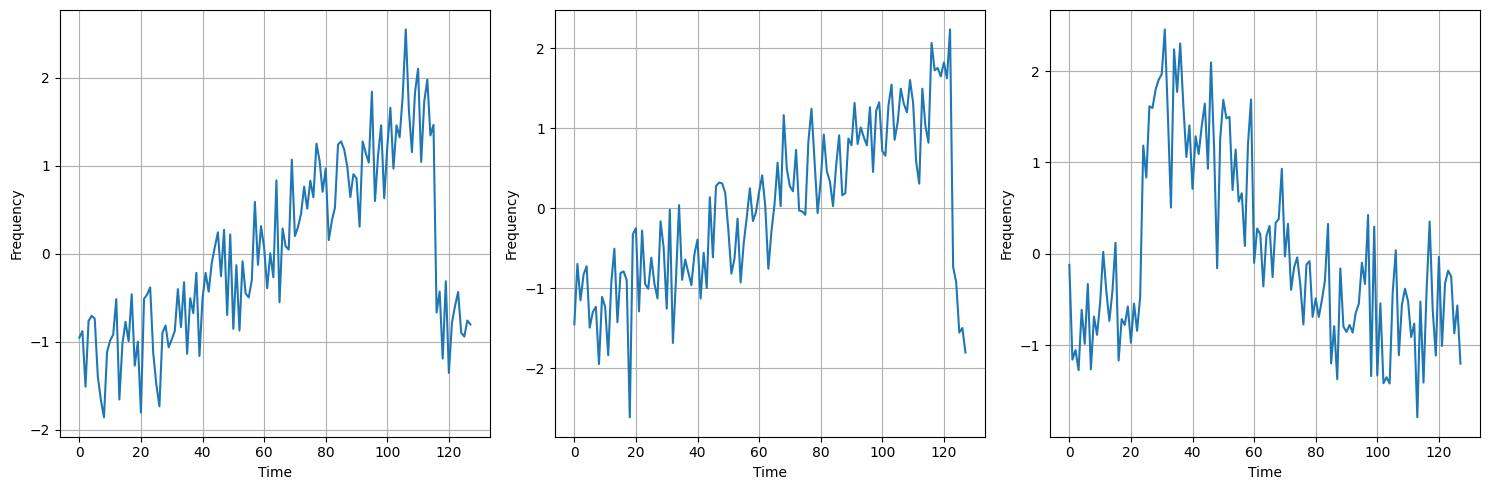

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indices = [3, 4, 5]

for i, idx in enumerate(indices):
    axes[i].plot(X_train[idx])
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)

plt.tight_layout()
plt.savefig("fig/Série a ser analisada")
plt.show()

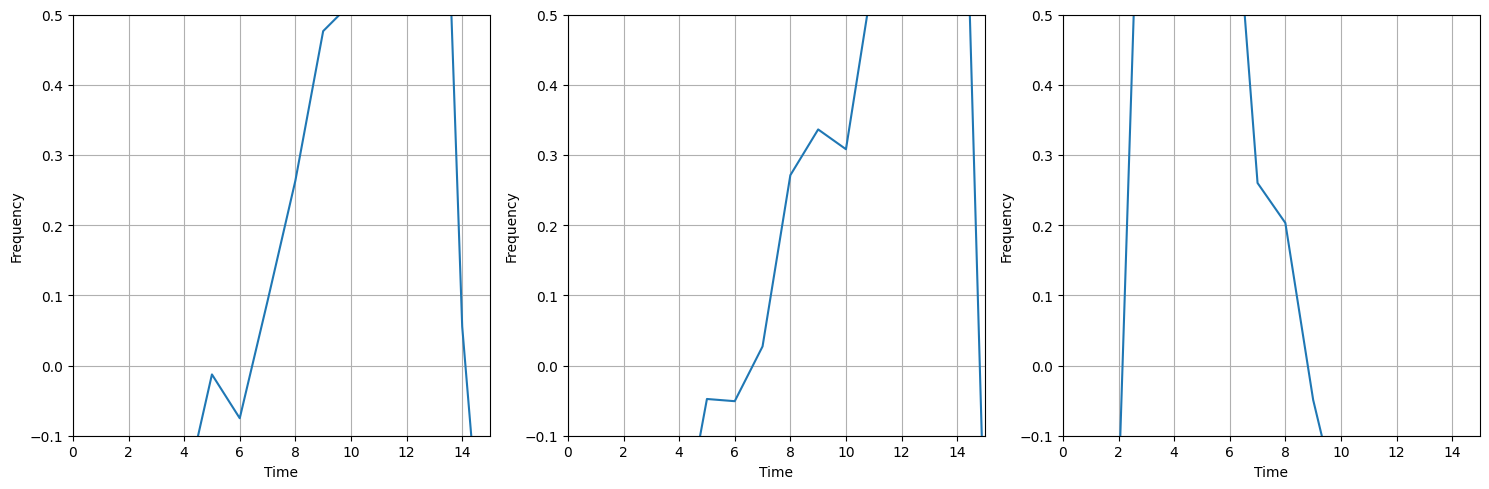

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indices = [3, 4, 5]

for i, idx in enumerate(indices):
    axes[i].plot(encoded[idx])
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)
    axes[i].set_xlim(0, X_train.shape[1] / modelo.pool_size - 1)
    axes[i].set_ylim(-0.1, 0.5)

plt.tight_layout()
plt.savefig("fig/Representação no espaço latente")
plt.show()



In [ ]:
X_test_scaled = scaler.fit_transform(
    X_test.reshape(-1, 2)
).reshape(X_test.shape)

In [ ]:
y_test_pred = modelo.predict(X_test)

y_test_aligned = np.array([mapping[c] for c in y_test_pred])
acc = (y_test_aligned == y_test).mean()

In [ ]:
y_test

array([1, 1, 1, 3, 2, 2, 1, 3, 2, 1, 2, 2, 1, 2, 2, 3, 2, 2, 1, 3, 2, 2,
       1, 1, 3, 3, 2, 3, 3, 1])

In [ ]:
y_test_aligned

array([3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 1, 3, 1, 3, 1, 1, 1, 3, 2, 1,
       3, 3, 3, 3, 3, 3, 3, 3])